In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt



def read_log(log_file_path="../logs/test.log"):
    with open(log_file_path, "r", encoding="utf-8") as f:
        log_text = f.read()
    
    # Define regex
    round_pattern = re.compile(r"----------------round: (\d+)")
    index_creation_cost_pattern = re.compile(r"Index creation cost: ([\d.]+)")
    total_query_time_pattern = re.compile(r"Time taken to run the queries: ([\d.]+)")
    analytical_time_pattern = re.compile(r"Time taken for analytical queries: ([\d.]+)")
    transactional_time_pattern = re.compile(r"Time taken for transactional queries: ([\d.]+)")
    size_pattern = re.compile(r"Size taken by the config: ([\d.]+)MB")
    recommendation_cost_pattern = re.compile(r"Recommendation cost: ([\d.]+), Hyp Component: ([\d.]+)")
    total_cost_pattern = re.compile(r"current total \d+: ([\d.]+), this round: ([\d.]+)")
    
    # Extract data
    data = []
    rounds = list(round_pattern.finditer(log_text))
    for i, match in enumerate(rounds):
        start = match.end()
        end = rounds[i + 1].start() if i + 1 < len(rounds) else len(log_text)
        round_text = log_text[start:end]
    
        round_data = {
            "round": int(match.group(1)),
            "index_creation_cost": float(index_creation_cost_pattern.search(round_text).group(1)) if index_creation_cost_pattern.search(round_text) else None,
            "total_query_time": float(total_query_time_pattern.search(round_text).group(1)) if total_query_time_pattern.search(round_text) else None,
            "analytical_time": float(analytical_time_pattern.search(round_text).group(1)) if analytical_time_pattern.search(round_text) else None,
            "transactional_time": float(transactional_time_pattern.search(round_text).group(1)) if transactional_time_pattern.search(round_text) else None,
            "config_size_mb": float(size_pattern.search(round_text).group(1)) if size_pattern.search(round_text) else None,
            "recommendation_cost": float(recommendation_cost_pattern.search(round_text).group(1)) if recommendation_cost_pattern.search(round_text) else None,
            "hyp_component": float(recommendation_cost_pattern.search(round_text).group(2)) if recommendation_cost_pattern.search(round_text) else None,
            "total_cost": float(total_cost_pattern.search(round_text).group(1)) if total_cost_pattern.search(round_text) else None,
            "this_round_cost": float(total_cost_pattern.search(round_text).group(2)) if total_cost_pattern.search(round_text) else None,
        }
        data.append(round_data)
    
    df = pd.DataFrame(data)

    return df

In [2]:
df = read_log(log_file_path="../logs/test_3.log")

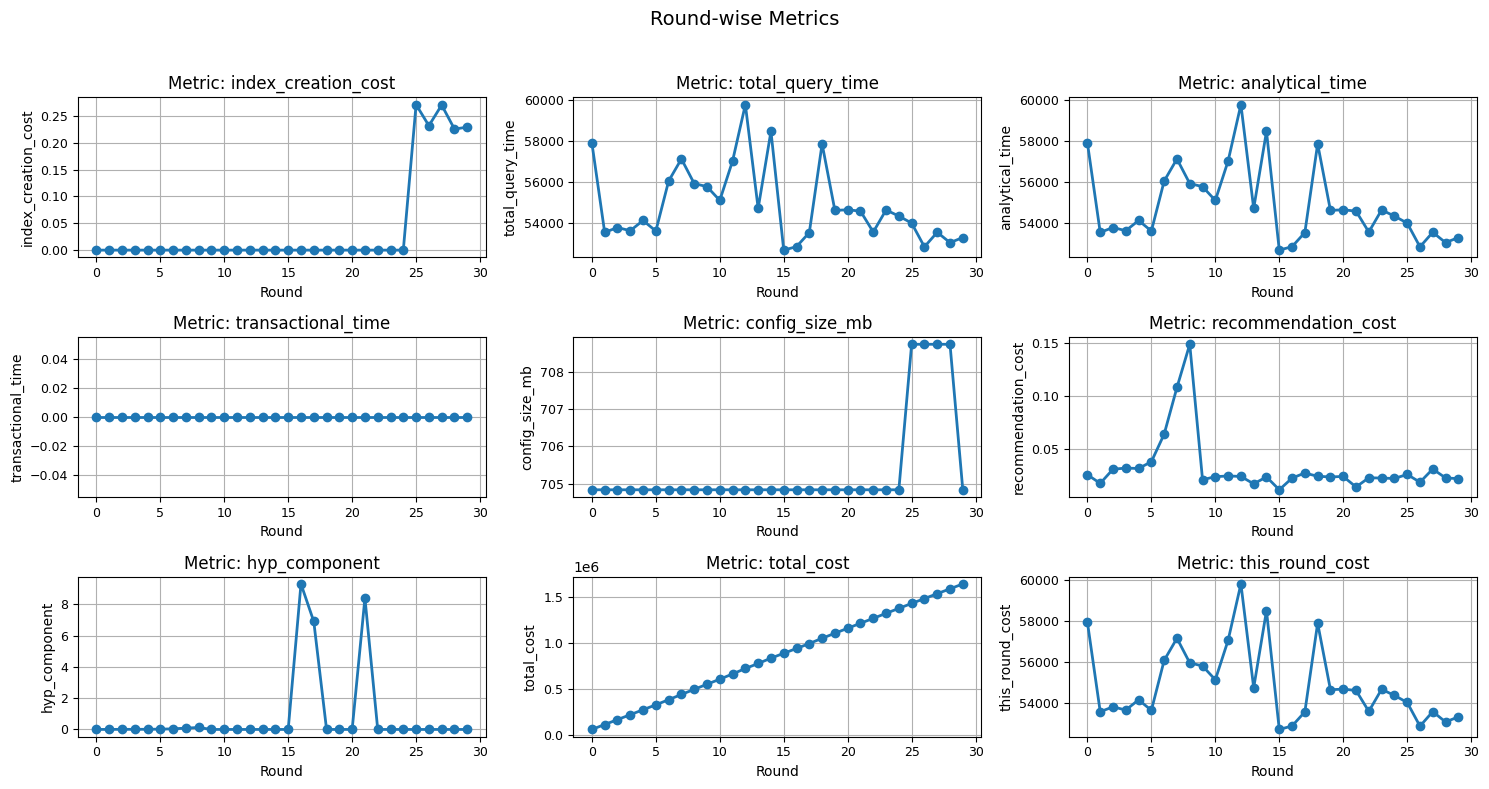

In [3]:
import matplotlib.pyplot as plt

def plot_metrics(df, metrics, title_prefix="Metric: ", figsize=(15, 8)):
    """
    Plot each metric in `metrics` as a separate line plot from the dataframe `df`.
    
    Parameters:
        df (pd.DataFrame): Must contain a 'round' column and metric columns
        metrics (list of str): List of column names to plot
        title_prefix (str): Title prefix for each subplot
        figsize (tuple): Size of the overall figure
    """
    n = len(metrics)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axs = plt.subplots(nrows, ncols, figsize=figsize)
    axs = axs.flatten()

    for i, metric in enumerate(metrics):
        ax = axs[i]
        ax.plot(df["round"], df[metric], marker='o', linewidth=2)
        ax.set_title(f"{title_prefix}{metric}", fontsize=12)
        ax.set_xlabel("Round", fontsize=10)
        ax.set_ylabel(metric, fontsize=10)
        ax.grid(True)
        ax.tick_params(axis='both', which='major', labelsize=9)

    # Hide any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    fig.suptitle("Round-wise Metrics", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Example usage:
plot_metrics(df, ['index_creation_cost', 'total_query_time', 'analytical_time', 'transactional_time'
                 ,'config_size_mb', 'recommendation_cost', 'hyp_component', 'total_cost', 'this_round_cost'])

